# Chapter 4 NumPy Basics: Array and Vectorized Computation

#### Note
1. Numpy internally stores data in c contiguous block of memory, independent of other built-in Python objects. Numpy arrays also use much less memory than built-in Python sequences.
2. Numpy operations perform complex computations on entire arrays without the need for Python for loops.
3. Numpy is faster than regular Python code because its C-based algorithms avoid overhead present with regular interpreted Python code.

In [1]:
import numpy as np
import sys

In [2]:
my_arr = np.arange(1_000_000)
my_list = list(range(1_000_000))

In [3]:
# %timeit my_arr2 = my_arr * 2

2.12 ms ± 305 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [4]:
# %timeit my_list2 = [x * 2 for x in my_list]

108 ms ± 31.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## 4.1 The Numpy ndarray: A Multidimensional Array Object

In [5]:
data = np.array([[1.5, -0.1, 3], [0, -3, 6.5]])
data

array([[ 1.5, -0.1,  3. ],
       [ 0. , -3. ,  6.5]])

In [6]:
data * 10

array([[ 15.,  -1.,  30.],
       [  0., -30.,  65.]])

In [7]:
data + data

array([[ 3. , -0.2,  6. ],
       [ 0. , -6. , 13. ]])

In [8]:
data.shape

(2, 3)

In [9]:
# All of the elements in an ndarray must have the same type
data.dtype

dtype('float64')

### Creating ndarrays

In [10]:
data1 = [6, 6.5, 8, 0, 1]
arr1 = np.array(data1)
arr1

array([6. , 6.5, 8. , 0. , 1. ])

In [11]:
arr1.dtype

dtype('float64')

In [12]:
data2 = [[1, 2, 3, 4], [5, 6, 7, 8]]
arr2 = np.array(data2)
arr2

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [13]:
arr2.dtype

dtype('int64')

In [14]:
print(arr1.ndim)
print(arr2.ndim)

1
2


In [15]:
zero_arr = np.zeros(10)
zero_arr

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [16]:
one_arr = np.ones((3, 4))
one_arr

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [17]:
empty_arr = np.empty((2, 3, 2))
empty_arr

array([[[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]]])

In [18]:
# numpy.arange is an array-valued version of the built-in Python range function
arr3 = np.arange(10)
print(arr3)
print(type(arr3))

arr4 = range(10)
print(arr4)
print(type(arr4))

[0 1 2 3 4 5 6 7 8 9]
<class 'numpy.ndarray'>
range(0, 10)
<class 'range'>


### Data Types for ndarrays

In [19]:
arr1 = np.array([1, 2, 3], dtype=np.float64)
arr2 = np.array([1, 2, 3], dtype=np.int8)
print(arr1.dtype)
print(arr2.dtype)
print(sys.getsizeof(arr1))
print(sys.getsizeof(arr2))

float64
int8
136
115


In [20]:
int_array = np.arange(10)
calibers = np.array([.22, .27, .440, .50], dtype=np.float64)

In [21]:
print(int_array)
print(int_array.dtype)

[0 1 2 3 4 5 6 7 8 9]
int64


In [22]:
int_array = int_array.astype(calibers.dtype)
print(int_array)
print(int_array.dtype)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
float64


In [23]:
numeric_strings = np.array(["-1", "-2.0", "0.99"])
numeric_strings

array(['-1', '-2.0', '0.99'], dtype='<U4')

In [24]:
numeric_strings.astype(np.float64)

array([-1.  , -2.  ,  0.99])

### Arithmetic with Numpy Arrays

Any arithmetic operations between equal-size arrays apply the operation element-wist.

In [25]:
arr = np.array([[1., 2., 3.], [4., 5., 6.]])

In [26]:
arr * arr

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [27]:
arr - arr

array([[0., 0., 0.],
       [0., 0., 0.]])

Arithmetic operations with scalars propagate the scalar argument to each element in the array

In [28]:
1 / arr

array([[1.        , 0.5       , 0.33333333],
       [0.25      , 0.2       , 0.16666667]])

In [29]:
arr ** 2

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [30]:
arr2 = np.array([[0., 4., 1.], [7., 2., 12.]])
arr2 > arr

array([[False,  True, False],
       [ True, False,  True]])

### Basic Indexing and Slicing

In [31]:
arr = np.arange(10)
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [32]:
arr[5]

5

In [33]:
arr[5:8]

array([5, 6, 7])

In [34]:
# A slice of numpy array is the view of the array, which is not a copy
# of part of the array. That means any modifications to the view will be
# reflected on the original array.

arr[5:8] = 12
print(arr)

x = arr[5:8]
x[:] = 14
print(arr)

[ 0  1  2  3  4 12 12 12  8  9]
[ 0  1  2  3  4 14 14 14  8  9]


In [35]:
list1 = [0, 1, 2, 3, 4, 5, 6]

# if we want to assign 12 to the third and forth elements in list1
# we cannot write as list1[2:4] = 12, the right hand side must be a list
# has the same length as the left list slice
list1[2:4] = [12, 12]
print(list1)

y = list1[2:4]
print(y)
for i in range(0, len(y)):
    y[i] = -1

print(y)
print(list1)

[0, 1, 12, 12, 4, 5, 6]
[12, 12]
[-1, -1]
[0, 1, 12, 12, 4, 5, 6]


For a multi-dimensions array, we can access it through any of its axises

In [36]:
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2]])

In [37]:
# Indexing by axis 0 (row)
data[0]

array([4, 7])

In [38]:
# Indexing by axis 1 (column)
data[:, 1]

array([7, 2, 6, 0, 2])

In [39]:
data[0:2, 1]

array([7, 2])

In [40]:
# Indexing by all axises
print(data[1, 1])

# The indexing can be discrete
# For example we can the second column in the first and forth row
# The discrete index belong to one axis should be in a list
print(data[[0, 3], 1])

# Access the first column of the first row and the second column of the third row
print(data[[0, 2], [0, 1]])

2
[7 0]
[4 6]


### Boolean Indexing

In [41]:
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2]])
names = np.array(["Bob", "Joe", "Will", "Bob", "Will"])

data[[1, 2], [0, 1]]

array([0, 6])

In [42]:
names == "Bob"

array([ True, False, False,  True, False])

In [43]:
print(names != "Bob")
# negate operator
print(~(names == "Bob"))

[False  True  True False  True]
[False  True  True False  True]


In [44]:
data[names == "Bob"]

array([[4, 7],
       [0, 0]])

In [45]:
data[names != "Bob"]

array([[ 0,  2],
       [-5,  6],
       [ 1,  2]])

In [46]:
data[~(names == "Bob")]

array([[ 0,  2],
       [-5,  6],
       [ 1,  2]])

In [47]:
cond = names == "Bob"
data[~cond]

array([[ 0,  2],
       [-5,  6],
       [ 1,  2]])

In [48]:
# & (and operator) and | (or operator)
cond = (names == "Bob") | (names == "Joe")
print(data[cond])

[[4 7]
 [0 2]
 [0 0]]


In [49]:
print(data < 0)
data[data < 0] = 0
print(data)

[[False False]
 [False False]
 [ True False]
 [False False]
 [False False]]
[[4 7]
 [0 2]
 [0 6]
 [0 0]
 [1 2]]


### Fancy Indexing

In [50]:
arr = np.zeros((8, 4))

for i in range(arr.shape[0]):
    arr[i] = i

arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

In [51]:
arr[[0, 3, 1, 4]]

array([[0., 0., 0., 0.],
       [3., 3., 3., 3.],
       [1., 1., 1., 1.],
       [4., 4., 4., 4.]])

In [52]:
arr[[-1, -5, -3]]

array([[7., 7., 7., 7.],
       [3., 3., 3., 3.],
       [5., 5., 5., 5.]])

In [53]:
arr = np.arange(32).reshape(8, 4)
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [54]:
arr[[1, 5, 7, 2], [0, 3, 1, 2]]

array([ 4, 23, 29, 10])

In [55]:
sub_arr = arr[[1, 5, 7, 2], [0, 3, 1, 2]]
print(sub_arr)
sub_arr[:] = 0
print(sub_arr)
print(arr)

[ 4 23 29 10]
[0 0 0 0]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]
 [24 25 26 27]
 [28 29 30 31]]


### Reshaping Arrays

In [56]:
arr = np.arange(8)

In [57]:
# arr.reshape() will return the view of the original array,
# That means the reshaped array share the same data buffer with original array.
# The changes made to the reshaped array will affect the original array
reshaped_arr = arr.reshape((4, 2))
reshaped_arr[0, 0] = 99
arr

array([99,  1,  2,  3,  4,  5,  6,  7])

In [58]:
# One of the passed shape dimensions can be -1, in which case the value used
# for that dimension will be inferred from the data
arr = np.arange(24)
arr = arr.reshape((2, 2, -1))
arr

array([[[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]],

       [[12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]]])

In [59]:
# arr.ravel() will return a view of the original array
raveled_arr = arr.ravel()
raveled_arr[0] = -99
print(arr)

[[[-99   1   2   3   4   5]
  [  6   7   8   9  10  11]]

 [[ 12  13  14  15  16  17]
  [ 18  19  20  21  22  23]]]


In [60]:
# arr.flatten() will return a copy of the original array
flattened_arr = arr.flatten()
flattened_arr[0] = 100
print(arr)

[[[-99   1   2   3   4   5]
  [  6   7   8   9  10  11]]

 [[ 12  13  14  15  16  17]
  [ 18  19  20  21  22  23]]]


### Transposing Arrays and Swapping Axes

In [61]:
arr = np.arange(15).reshape((3, 5))
arr

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [62]:
# arr.T will return the view of the original array
# Any changes on the transposed array will reflect on the original array
transposed_arr = arr.T
transposed_arr[0] = -1
arr

array([[-1,  1,  2,  3,  4],
       [-1,  6,  7,  8,  9],
       [-1, 11, 12, 13, 14]])

In [63]:
np.dot(arr, arr.T)

array([[ 31,  81, 131],
       [ 81, 231, 381],
       [131, 381, 631]])

In [64]:
arr @ arr.T

array([[ 31,  81, 131],
       [ 81, 231, 381],
       [131, 381, 631]])

In [65]:
arr.swapaxes(0, 1)

array([[-1, -1, -1],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

In [66]:
arr.swapaxes(1, 0)

array([[-1, -1, -1],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

## 4.1 The Numpy ndarray: Summarizations

### Functions return a view
In Numpy most of the built-in functions have a favor to return a view on the original array, as this package is designed for processing large dataset.

In [67]:
# Slicing
arr = np.arange(10)
view = arr[1:5]

In [68]:
# Reshape, if reshape do not requires changing the memeory layout
arr = np.arange(6)
view = arr.reshape((2, 3))

In [69]:
# Transpose
arr = np.arange(16)
arr = arr.reshape((2, 8))
view = arr.T


In [70]:
# ravel
arr = np.arange(8)
arr = arr.reshape((4, 2))
print(arr)
arr.ravel()


[[0 1]
 [2 3]
 [4 5]
 [6 7]]


array([0, 1, 2, 3, 4, 5, 6, 7])

### Functions that return a copy

In [71]:
arr = np.arange(10)
copy = arr.copy()

In [72]:
# flatten
arr = np.arange(10)
arr = arr.reshape((2, 5))
copy = arr.flatten()

In [73]:
# Advanced indexing
arr = np.arange(10)
copy = arr[[1, 3, 5]]

copy = arr[arr > 5]

In [74]:
# astype
arr = np.arange(10, dtype=np.int32)
copy = arr.astype(np.float64)

## 4.2 Pseudorandom Number Generation

In [75]:
# np.random.standard_norm() use numpy.random module's default random number generator
samples = np.random.standard_normal(size=(4, 4))

# But we can also use explict generator
rng = np.random.default_rng(seed=12345)
data = rng.standard_normal((2, 3))
print(data)

[[-1.42382504  1.26372846 -0.87066174]
 [-0.25917323 -0.07534331 -0.74088465]]


In [76]:
# if you want to generated the same random number you must reseed the
# random number generator after using
rng = np.random.default_rng(seed=12345)
x = rng.standard_normal(8)
y = rng.standard_normal(8)
print(x)
print(y)

# reseed the rng
rng = np.random.default_rng(seed=12345)
a = rng.standard_normal(size=8)
b = rng.standard_normal(size=8)
print(a)
print(b)

[-1.42382504  1.26372846 -0.87066174 -0.25917323 -0.07534331 -0.74088465
 -1.3677927   0.6488928 ]
[ 0.36105811 -1.95286306  2.34740965  0.96849691 -0.75938718  0.90219827
 -0.46695317 -0.06068952]
[-1.42382504  1.26372846 -0.87066174 -0.25917323 -0.07534331 -0.74088465
 -1.3677927   0.6488928 ]
[ 0.36105811 -1.95286306  2.34740965  0.96849691 -0.75938718  0.90219827
 -0.46695317 -0.06068952]


## 4.3 Universal Functions: Fast Element-Wise Array Functions

A universal function, or ufunc, is a function that performs element-wise operations on data in ndarrays. You can think of them as fast vectorized wrappers for simple functions that take one or more scalar values and produce one or more scalar results.

### Unary ufuncs
Many ufuncs are simple element-wise transformations, like np.sqrt or np.exp

In [77]:
arr = np.arange(10)
print(arr)
np.sqrt(arr)

[0 1 2 3 4 5 6 7 8 9]


array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

In [78]:
np.exp(arr)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

### Binary ufuncs
np.add or np.maximum take two arrays and return a single array as the result.

In [79]:
rng = np.random.default_rng(seed=12345)

In [80]:
x = rng.standard_normal(8)
y = rng.standard_normal(8)
print(x)
print(id(x))
print(y)
print(id(y))

[-1.42382504  1.26372846 -0.87066174 -0.25917323 -0.07534331 -0.74088465
 -1.3677927   0.6488928 ]
137544179379408
[ 0.36105811 -1.95286306  2.34740965  0.96849691 -0.75938718  0.90219827
 -0.46695317 -0.06068952]
137544179378448


In [81]:
z = np.maximum(x, y)
print(z)
print(id(z))
print(z is x)

[ 0.36105811  1.26372846  2.34740965  0.96849691 -0.07534331  0.90219827
 -0.46695317  0.6488928 ]
137544179372496
False


### Unfuncs accept an optional out argument that allows them to assign their results into an existing array rather than create a new one.
This functionality can be very useful when we want ot save the memory usage of our system.

In [82]:
z1 = np.maximum(x, y, out=x)
print(z1)
print(id(z1))
print(z1 is x)

[ 0.36105811  1.26372846  2.34740965  0.96849691 -0.07534331  0.90219827
 -0.46695317  0.6488928 ]
137544179379408
True


In [83]:
x = np.arange(10)
print(type(x))
y = range(10)
print(type(y))

z = np.add(x, 1)
print(z)
print(id(z))
print(z is x)

z1 = np.add(x, 1, out=x)
print(z1)
print(id(z1))
print(z1 is x)

<class 'numpy.ndarray'>
<class 'range'>
[ 1  2  3  4  5  6  7  8  9 10]
137544179380848
False
[ 1  2  3  4  5  6  7  8  9 10]
137544179382000
True


## 4.4 Array-Oriented Programming with Arrays

In [84]:
points = np.arange(-5, 5, 0.01) # 100 equally spaced points

xs, ys = np.meshgrid(points, points)

In [85]:
ys

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]])

In [86]:
# we want to evaluate the function sqrt(x^2 + y^2) across a regular grid of values.
z = np.sqrt(xs ** 2 + ys ** 2)
z

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985,
        7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603,
        7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568]])

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

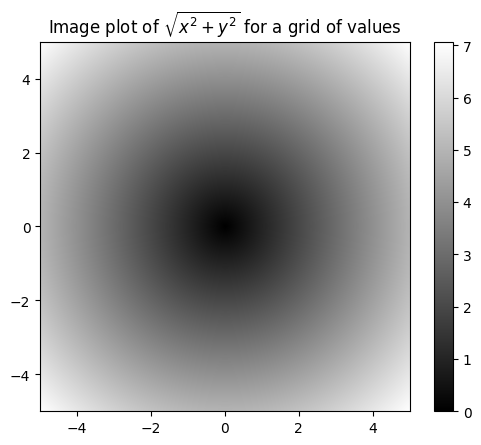

In [87]:
import matplotlib.pyplot as plt

plt.imshow(z, cmap=plt.cm.gray, extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")


In [88]:
plt.close("all")

### Expressing Conditional Logic as Array Operations


The numpy.where function `np.where(cond, x, y)` is a vectoried version of the ternary expression `x if condition else y`.

In [89]:
# Suppose we have two arrays of values and a boolean array
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

In [90]:
result = np.where(cond, xarr, yarr)
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

np.where is usually used to create a new array

In [92]:
arr = rng.standard_normal((4, 4))

In [93]:
arr > 0

array([[ True, False,  True,  True],
       [ True, False,  True, False],
       [False,  True, False, False],
       [ True,  True,  True,  True]])

When only condition is provided in the np.where function, it will return the coordinates of the points where the condition is True. And it is equivalent to `np.asarray(condition).nonzero()`, based on Numpy official document using nonzero function should be preferred in this situation.

In [94]:
np.where(arr > 0)

(array([0, 0, 0, 1, 1, 2, 3, 3, 3, 3]), array([0, 2, 3, 0, 2, 1, 0, 1, 2, 3]))

In [96]:
np.asarray(arr > 0)

array([[ True, False,  True,  True],
       [ True, False,  True, False],
       [False,  True, False, False],
       [ True,  True,  True,  True]])

In [97]:
# Create a new array where arr > 0 the elements are 2,
# otherwise the elements are -2
np.where(arr > 0, 2, -2)

array([[ 2, -2,  2,  2],
       [ 2, -2,  2, -2],
       [-2,  2, -2, -2],
       [ 2,  2,  2,  2]])

In [100]:
# Create a new array where arr > 0, the elements are equal to
# the corresponding values in arr, otherwise the elements are -2
np.where(arr > 0, arr, -2)

array([[ 0.78884434, -2.        ,  0.57585751,  1.39897899],
       [ 1.32229806, -2.        ,  0.90291934, -2.        ],
       [-2.        ,  0.44948393, -2.        , -2.        ],
       [ 1.72473993,  2.61815943,  0.77736134,  0.8286332 ]])

### Mathematical and Statistical Methods